In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline
uploaded = files.upload()
iris_svm_filename = next(iter(uploaded))
i_svm = pd.read_csv(io.StringIO(uploaded[iris_svm_filename].decode('utf-8')))
display(i_svm.head())

Saving iris_svm.csv to iris_svm.csv


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
v_nv_fn = lambda x: 0 if x=="versicolor" else 1
# new column added into dataframe
i_svm["v_nv"] = i_svm["Species"].apply(v_nv_fn)
i_svm[i_svm['v_nv']==0].head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,v_nv
50,7.0,3.2,4.7,1.4,versicolor,0
51,6.4,3.2,4.5,1.5,versicolor,0
52,6.9,3.1,4.9,1.5,versicolor,0
53,5.5,2.3,4.0,1.3,versicolor,0
54,6.5,2.8,4.6,1.5,versicolor,0


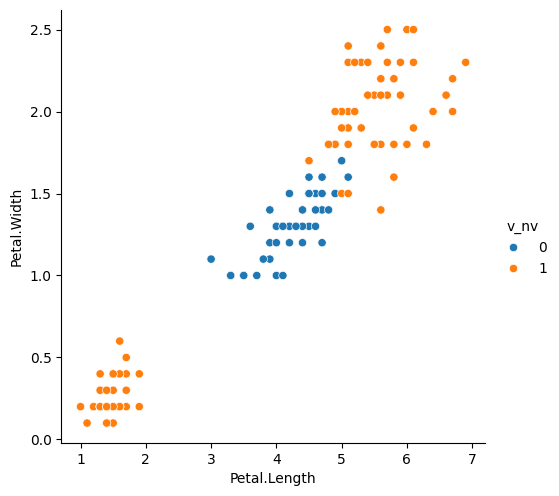

In [3]:
#visualization using seaborn - pairplot
import seaborn as sns
sns.pairplot(i_svm,
             x_vars = "Petal.Length",y_vars="Petal.Width",
             hue="v_nv",height=5)


In [4]:
#Support Vector Classification
from sklearn.svm import SVC
X = i_svm[["Petal.Length","Petal.Width"]]
Y = i_svm["v_nv"]
model = SVC()
model.fit(X,Y)
model.score(X,Y)

0.9533333333333334

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Decision boundary of SVM on iris data')

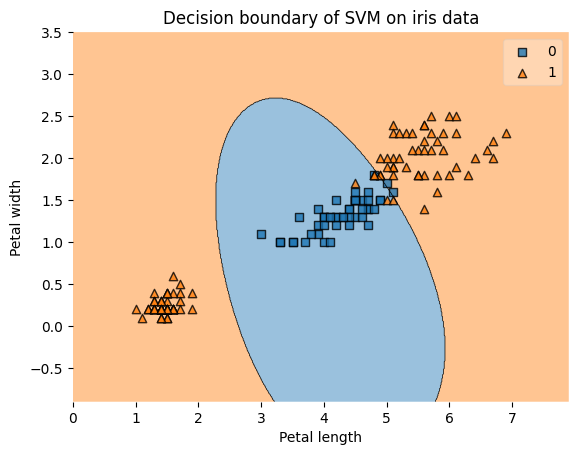

In [5]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(Y).ravel()
plot_decision_regions(features,target,clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title('Decision boundary of SVM on iris data')


In [6]:
# encoding the species column
i_svm.loc[i_svm.Species=="setosa","Species"] = 0
i_svm.loc[i_svm.Species=="versicolor","Species"] = 1
i_svm.loc[i_svm.Species=="virginica","Species"] = 2
i_svm.Species = i_svm.Species.astype("category")
i_svm.head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,v_nv
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [8]:
X = i_svm[["Petal.Length","Petal.Width"]]
Y = i_svm["Species"]
model = SVC()
model.fit(X,Y)


SVC()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Multiclass classification on iris using SVM')

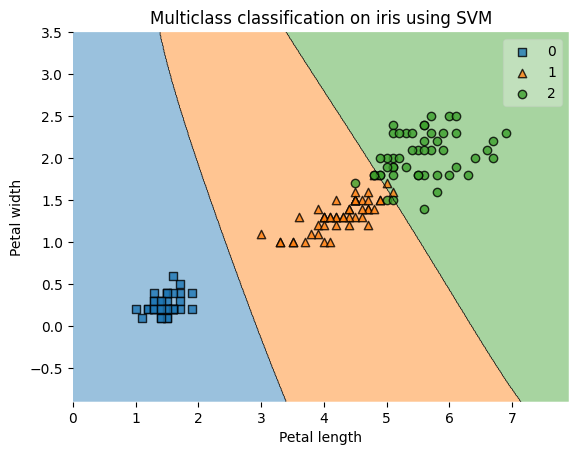

In [9]:
from mlxtend.plotting import plot_decision_regions
features = np.array(X)
target = np.array(Y)
plot_decision_regions(features,target,clf=model)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title('Multiclass classification on iris using SVM')
